# Imports
Use fastai conda environment for consistent versioning

In [2]:
import shutil
import re
import os
import sys
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
from numpy import random
from scipy import stats
import pickle

# import fastai.tabular.all as fasttab
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestClassifier,  GradientBoostingRegressor
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.utils import resample
import sklearn.metrics as skm


sys.path.append('/mnt/scripts/biliseq_he_class2')
from helpers import anno as annoHelper
%load_ext autoreload
%autoreload 2


results = Path('/mnt/results/v8/')
models = results.joinpath('models')
use_model = 'densenet169_1fold_1rep_10933bal_224px'
method = 'slide'
csv_path = models.joinpath(use_model).joinpath('csv')
logs = Path('/mnt/logs/v8/training').joinpath('%s_v1' % use_model)
sampleinfo = Path('/mnt/sampleinfo')
# slide_df = pd.read_csv(sampleinfo.joinpath('test_slide_df_v8.0_388.tsv'),sep='\t').drop(columns=['Unnamed: 0'])
# slide_df = pd.read_csv(sampleinfo.joinpath('test_slide_df_v8.0_391_v2.tsv',sep='\t')
slide_df = pd.read_csv(sampleinfo.joinpath('rand_valid_100slides_97cases_v4.tsv'),sep='\t')
infer_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('infer_csv').joinpath('testset')
feat_path = results.joinpath('features').joinpath(use_model).joinpath('testset')
feat_path.mkdir(parents=True,exist_ok=True)
tab_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('tab_models')
print('Finished')

Finished


In [3]:
def vector_to_pbins_index(dat,pbins):
    out = np.zeros(dat.shape)
    for i,pbin in enumerate(pbins):
        idx = (dat >= pbin[0]) & (dat < pbin[1])
        out[idx] = i
    return out

def calc_feats(slide_df,
               tile_df,
               put_pos_thresh=0.16,
               norm=True):
    more_feat = pd.DataFrame([])
    slides = slide_df.slide_num.values
    best_t = put_pos_thresh
    for slide in slides:
        use = tile_df.slide == slide
        tsub=tile_df.loc[use,:].reset_index(drop=True)
        dat = tsub.p_pos.values
        more_feat.loc[slide,'mean_ppos'] = np.mean(dat)
        more_feat.loc[slide,'std_ppos'] = np.std(dat)
        more_feat.loc[slide,'median_ppos'] = np.median(dat)
        more_feat.loc[slide,'var_ppos'] = np.var(dat)        
        more_feat.loc[slide,'mean_ppos_over_bestt'] = int(np.mean(dat) > best_t)
        
        put_pos = dat>best_t
        if any(put_pos):
            more_feat.loc[slide,'prop_ppos'] = np.sum(put_pos)/len(dat)
            more_feat.loc[slide,'put_pos_mean'] = np.mean(dat[put_pos])
            more_feat.loc[slide,'put_pos_psum'] = np.sum(dat[put_pos])
            more_feat.loc[slide,'put_pos_std'] = np.std(dat[put_pos])
            more_feat.loc[slide,'put_pos_max'] = np.max(dat[put_pos])
            more_feat.loc[slide,'put_pos_min'] = np.min(dat[put_pos])
            more_feat.loc[slide,'put_pos_var'] = np.var(dat[put_pos])
        else:
            more_feat.loc[slide,'prop_ppos'] = 0
            more_feat.loc[slide,'put_pos_mean'] = 0
            more_feat.loc[slide,'put_pos_psum'] = 0
            more_feat.loc[slide,'put_pos_std'] = 0
            more_feat.loc[slide,'put_pos_max'] = 0
            more_feat.loc[slide,'put_pos_min'] = 0
            more_feat.loc[slide,'put_pos_var'] = 0
        
        more_feat.loc[slide,'put_neg_max'] = np.max(dat[~put_pos])
        more_feat.loc[slide,'put_neg_psum'] = np.sum(dat[~put_pos])
        more_feat.loc[slide,'put_neg_mean'] = np.mean(dat[~put_pos])
        more_feat.loc[slide,'put_neg_min'] = np.min(dat[~put_pos])
        more_feat.loc[slide,'put_neg_std'] = np.std(dat[~put_pos])
        more_feat.loc[slide,'put_neg_var'] = np.var(dat[~put_pos])
        
    stat_feat = more_feat.values
    #0-1 scaling
    if norm:            
        stat_feat = (stat_feat - np.min(stat_feat,axis=0))
        stat_feat = (stat_feat / np.max(stat_feat,axis=0))

    return stat_feat

#  Run inference on test slides using fully trained models (ALL TILES)
see : /model_fitting/infer/fastai_cnn_cv_train_inference_v8.py


# Load test slide inferences 

In [9]:
ifn = [str(x) for x in infer_path.glob('*.csv')]
folds = len(ifn)
valid = pd.DataFrame(slide_df.loc[:,['slide','group','class','accession_number']])
all_y_true = []
all_y_pred = []
tile_inf = {'slide':[], 'x':[], 'y':[], 'p_pos':[],'cls':[]}
    
for fold in range(0,folds):
    fn = infer_path.joinpath('%s_%d_all_valid_pred.csv' % (method,fold))
    if fn.exists():
        df = pd.read_csv(fn)        
        u_slide = df.slide.unique()
        if any(slide_df.slide.isin(u_slide)):
            for slide in u_slide:
                idx = slide_df.slide.values == slide
                slide_idx = df.slide.values == slide            
                tile_p = df.loc[slide_idx,'p_pos'].values            
                tile_cls= df.loc[slide_idx,'slide_class'].str.contains('malig').values

                xt=[]
                yt=[]
                st=[slide] * np.sum(slide_idx)
                for fn in df.loc[slide_idx,'cur_path'].values:
                    _,x,y,_ = annoHelper.parse_tile_fn(fn)
                    xt.append(x)
                    yt.append(y)

                tile_inf['x'].extend(xt)
                tile_inf['y'].extend(yt)
                tile_inf['slide'].extend(st)                
                tile_inf['p_pos'].extend(tile_p)
                tile_inf['cls'].extend(tile_cls)
    else:
        print('Missing',fn)
tile_df = pd.DataFrame(tile_inf)
tile_df = tile_df.dropna(how='any').reset_index(drop=True)
fn = feat_path.joinpath('infer_tile_df_%dt_%dslides.csv' % (tile_df.shape[0],
                                              len(tile_df.slide.unique()))
                       )
print(fn)
tile_df.to_csv(fn, index=False)
print(len(tile_df.slide.unique()),
      tile_df.shape[0])
tile_df.head()

Missing /mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/infer_csv/testset/slide_38_all_valid_pred.csv
Missing /mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/infer_csv/testset/slide_41_all_valid_pred.csv
Missing /mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/infer_csv/testset/slide_193_all_valid_pred.csv
Missing /mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/infer_csv/testset/slide_206_all_valid_pred.csv
Missing /mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/infer_csv/testset/slide_211_all_valid_pred.csv
/mnt/results/v8/features/densenet169_1fold_1rep_10933bal_224px/testset/infer_tile_df_1018347t_97slides.csv
97 1018347


,slide,x,y,p_pos,cls
0,1013757,19488,99008,4.648641e-05,True
1,1013757,29008,57680,6.102068e-07,True
2,1013757,16912,125776,1.246290e-05,True
3,1013757,17024,16576,2.541424e-04,True
4,1013757,33264,115248,1.808730e-05,True


In [7]:
print(len(tile_df.slide.unique()),
      tile_df.shape[0])

97 1018347


# Make validation summary

In [5]:
valid = pd.DataFrame(slide_df.loc[:,['slide','group','class','accession_number']])
for slide in tile_df.slide.unique():   
    slide_idx = tile_df.slide.values == slide
    idx = slide_df.slide.values == slide
    if np.any(slide_idx):
            tile_p = tile_df.loc[slide_idx,'p_pos'].values
            m_p = np.mean(tile_p)
            valid.loc[idx,'mean_p_pos'] = m_p
isnan = valid.mean_p_pos.isna().values #?
new_slide_df = slide_df.loc[~isnan,:]
valid = valid.dropna(how='any').reset_index(drop=True)
valid.head()

,slide,group,class,accession_number,mean_p_pos
0,1013926,benign,False,PHS20-10166 - 2 - 1013926,0.227191
1,400130,malignant,True,PHS20-31037 - 1 - 400130,0.235773
2,1014025,malignant,True,PHS19-7430 - 1014025,0.311441
3,1014063,benign,False,PHS19-8072 - 1014063,0.015590
4,1014031,benign,False,PHS19-1935 - 1014031,0.050000


In [11]:
# isnan = valid.mean_p_pos.isna().values #?
print(isnan.shape,slide_df.shape,new_slide_df.shape)
new_slide_df.index = new_slide_df.slide.values
print(np.sum(new_slide_df.index == valid.slide.values))


(100,) (100, 20) (97, 20)
97


# Validation set performance n = 97 slides

38 38


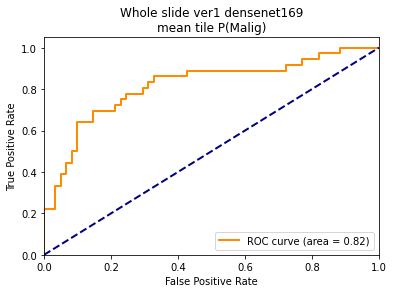

In [12]:
y_score = valid.mean_p_pos.values
y_true = valid.loc[:,'group'].str.contains('malig').astype(int).values
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=True)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whole slide ver1 densenet169\nmean tile P(Malig)")
plt.legend(loc="lower right")
plt.show()


Thresh 0.155 
Accuracy 0.7321731748726655 
Specificity 0.8064516129032258 
Sensitivity 0.6578947368421053
Thresh 0.25 
Accuracy 0.6651103565365025 
Specificity 0.9354838709677419 
Sensitivity 0.39473684210526316


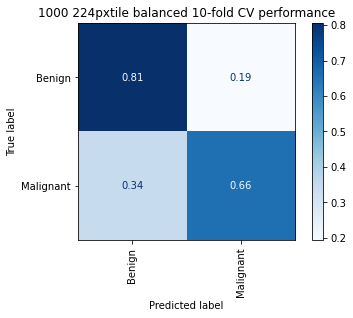

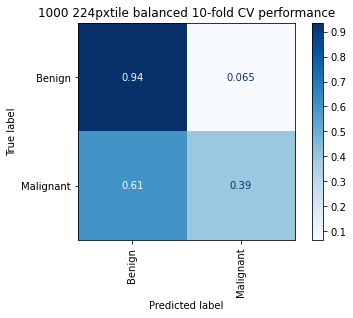

In [42]:
norm = True
#Values from notebook 04:
best_t = 0.155 #Calculated from 10fold CV on TRAINING SET (different cases and slides!)
best_spec = 0.25 #Calculated from 10fold CV on TRAINING SET (different cases and slides!)
threshes = [best_t, best_spec]
for use_t in threshes:
    y_true =  valid.loc[:,'class'].values
    y_pred = valid.mean_p_pos.values > use_t
    cm = skm.confusion_matrix(y_true, y_pred)
    if norm:
        cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
    disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Benign','Malignant'])
    ax=disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title('1000 224pxtile balanced 10-fold CV performance')


    ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
    sp = cm[0,0] / np.sum(cm,axis=1)[0]
    sen = cm[1,1] /  np.sum(cm,axis=1)[1]
    print('Thresh',use_t,
          '\nAccuracy',ac, 
          '\nSpecificity',sp,
          '\nSensitivity',sen)

# Extract spatial features

In [45]:
pbins = [[2.3306949e-19, 1.6597538e-07],
        [1.6599532e-07, 8.5704363e-07],
        [8.570608e-07, 2.6130247e-06],
        [2.6130695e-06, 6.6449984e-06],
        [6.6451694e-06, 1.5280224e-05],
        [1.528037e-05, 3.3370972e-05],
        [3.3372024e-05, 7.120561e-05],
        [7.1206094e-05, 0.00015340053],
        [0.00015340783, 0.0003436641],
        [0.0003436928, 0.0008139474],
        [0.0008139482, 0.0021406421],
        [0.0021406626, 0.006389423],
        [0.006389768, 0.022844505],
        [0.022844516, 0.10245558],
        [0.10246198, 0.44730905],
        [0.44731876, 0.89797425],
        [0.89798445, 0.9929132],
        [0.99291354, 0.99966085],
        [0.99966085, 0.99998987],
        [0.99998987, 1.0]]
nq = len(pbins) #20
n = 11 #num tile neighbors
p = n //2
ts = 224
slides =  new_slide_df.slide_num.values
features = pd.DataFrame([])
version = 2
print(use_model)
for slide in tqdm(slides):
    # print('\n' + str(slide))
    use = tile_df.slide == slide
    tsub=tile_df.loc[use,:].reset_index(drop=True)
    dat = tsub.p_pos.values
    if version == 1:
        qidx = vector_to_quantile_index(dat, nq) #Do this instead with flat p-value bins from 0-1 ??
    elif version == 2:
        qidx = vector_to_pbins_index(dat,pbins)
    axi=1
    all_neighbors=[]
    for i in range(0,nq):
        # print('%d,' % (i), end = '') # Way to prevent newline
        idx = np.argwhere(qidx == i).flatten()
        x_tot=[]
        y_tot=[]
        w_tot=[]
        if any(idx):
            for ii,tid in enumerate(idx):        
                xx,yy = tsub.loc[tid,['x','y']]
                xn = tsub.x.values - xx
                yn = tsub.y.values - yy
                keep = (xn >= -(p*ts)) & (xn < (p+2)*ts) \
                        & (yn >= -(p*ts)) & (yn < (p+2)*ts)
                x_tot.extend(xn[keep])
                y_tot.extend(yn[keep])
                w_tot.extend(dat[keep])
            x_bin = np.array([x for x in range(((-p * ts)),(p+3)*ts,ts)])
            y_bin = x_bin        
            nn,_,_ = np.histogram2d(x = x_tot,
                                    y = y_tot,
                                    bins = [x_bin,y_bin],
                                    density = True,
                                    weights = w_tot)
        else:
            nn = np.zeros((n+1,n+1))
        all_neighbors.extend(nn.ravel())
    features.loc[:,slide] = all_neighbors
tt = features.transpose()
fn = feat_path.joinpath('%dpbins_%ddim_%dslides_nbnormed_density_v%d.csv' % (nq,
                                                                            (n+1),
                                                                             tt.shape[0],
                                                                             version))
print(fn)
print(tt.shape)
tt.to_csv(fn)   

densenet169_1fold_1rep_10933bal_224px


100%|██████████| 97/97 [13:00<00:00,  8.05s/it]


/mnt/results/v8/features/densenet169_1fold_1rep_10933bal_224px/testset/20pbins_12dim_97slides_nbnormed_density_v2.csv
(97, 2880)


/mnt/results/v8/features/densenet169_1fold_1rep_10933bal_224px/testset/20pbins_12dim_100slides_nbnormed_density_v2.csv

# Load and create final featureset:
note: make new_slide_df above

In [6]:
npcs = 44
seed = 35
whiten = False
tt = pd.read_csv(feat_path.joinpath(
                '20pbins_12dim_97slides_nbnormed_density_v2.csv'),
                 index_col=0)
tile_df = pd.read_csv(feat_path.joinpath('infer_tile_df_1018347t_97slides.csv'))
all_space = tt.copy()

all_space = (all_space.T - np.min(tt, axis=1)).T
all_space = (all_space.T / np.max(all_space, axis=1)).T
all_space = all_space.dropna()
pca = PCA(n_components = npcs, 
          whiten=whiten,
          random_state=seed) # whiten=True)
X_r0 = pca.fit(all_space).transform(all_space)
use_norm = True
use_thresh = 0.25 #best spec for tiles see notebook 04
stat_feat =calc_feats(new_slide_df,
                      tile_df,
                      put_pos_thresh=use_thresh,
                      norm= use_norm) 
all_feat = np.concatenate((stat_feat,
                           X_r0),
                           axis=1) 
print(all_feat.shape)

(97, 62)


# Plot feature space using PCA

Text(0.5, 1.0, 'Kmeans = 2 of features')

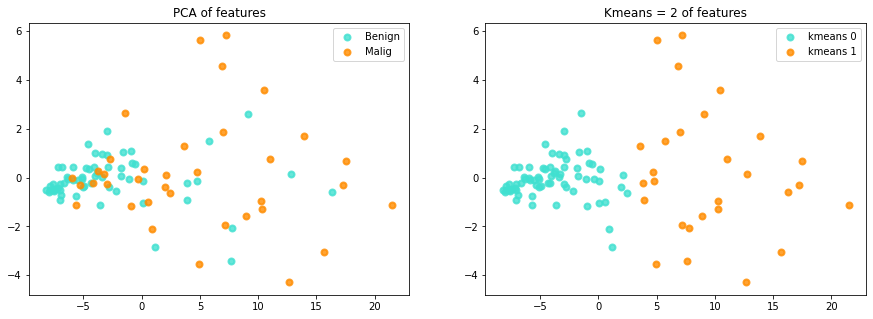

In [7]:
pca = PCA(n_components = 2)
X_r = pca.fit(all_feat).transform(all_feat)
y = new_slide_df.anno_class.str.contains('malig').values
target_names=['Benign','Malig']
fig = plt.figure(figsize=(15,5))
colors = ["turquoise", "darkorange"]
lw = 2

ax = fig.add_subplot(1,2,1)
for color, i, target_name in zip(colors, [0, 1], target_names):
    ax.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
ax.legend(loc="best", shadow=False, scatterpoints=1)
ax.set_title("PCA of features")


kmeans = KMeans(n_clusters=2, random_state=0).fit(all_feat)
y = kmeans.labels_
ax = fig.add_subplot(1,2,2)
target_names=['kmeans 0', 'kmeans 1']
for color, i, target_name in zip(colors, [0,1], target_names):
    ax.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
ax.legend(loc="best", shadow=False, scatterpoints=1)
ax.set_title("Kmeans = 2 of features")

# Perform tabular inference

In [8]:
use_rf = True
kfold = 10
rep = -1
fold_rep_tot = 100
gb_path = tab_path.joinpath('gb')
rf_path = tab_path.joinpath('rf')
print(gb_path,rf_path)
valid_preds = pd.DataFrame(np.zeros((new_slide_df.shape[0],fold_rep_tot))+np.nan)
valid_preds.index = new_slide_df.index #something like this, need equiv. of slide_df but with nan ind drop
for fold_rep in range(0,fold_rep_tot):
    fold = (fold_rep % kfold)
    if fold == 0:
        rep = rep+1
        
    fn='%02.0f_%02.0frep_%02.0ffold.pkl' % (fold_rep,rep,fold)
    gb_est = pickle.load(open(gb_path.joinpath(fn), 'rb'))
    X_val = all_feat
    y_val = new_slide_df.loc[:,'class'].values.astype(float)
    pred_gb = gb_est.predict(X_val)
    if use_rf:
        rf_est = pickle.load(open(rf_path.joinpath(fn), 'rb'))
        pred_rf = rf_est.predict_proba(X_val)[:,1]
        valid_preds.iloc[:,fold_rep]= (pred_gb*0.9 + pred_rf * 0.1)
    else:
        valid_preds.iloc[:,fold_rep]= pred_gb
    
print('Finished')

/mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/tab_models/gb /mnt/results/v8/models/densenet169_1fold_1rep_10933bal_224px/tab_models/rf
Finished


In [6]:
print(new_slide_df.shape, valid_preds.shape)

(97, 20) (97, 100)



Accuracy 0.6844262295081966 
Specificity 0.8688524590163934 
Sensitivity 0.5

Accuracy 0.7723132969034607 
Specificity 0.6557377049180327 
Sensitivity 0.8888888888888888


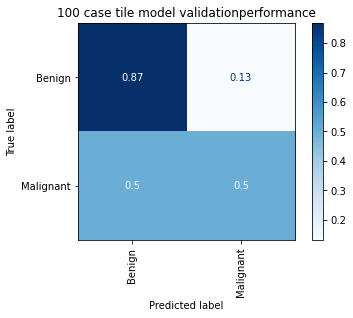

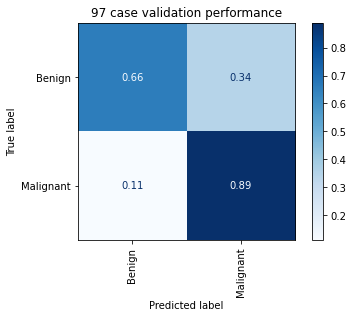

In [9]:
table_norm = True
nrep = 100
best_spec = 0.972 #Calculated with training set only! see notebook 07
best_t = 0.646 #Calculated with training set only! see notebook 07
use_reps = [x for x in range(0,nrep)]
y_pred = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_spec
y_true = new_slide_df.loc[:,'class'].values
cm = skm.confusion_matrix(y_true.astype(float), 
                          y_pred.astype(float))
if table_norm:
    cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign','Malignant'])
ax=disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('100 case tile model validationperformance')


ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
sp = cm[0,0] / np.sum(cm,axis=1)[0]
sen = cm[1,1] /  np.sum(cm,axis=1)[1]
print('\nAccuracy',ac, 
      '\nSpecificity',sp,
      '\nSensitivity',sen)

y_pred = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_t
y_true = new_slide_df.loc[:,'class'].values
cm = skm.confusion_matrix(y_true.astype(float), 
                          y_pred.astype(float))
if table_norm:
    cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign','Malignant'])
ax=disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('%d case validation performance' % new_slide_df.shape[0])


ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
sp = cm[0,0] / np.sum(cm,axis=1)[0]
sen = cm[1,1] /  np.sum(cm,axis=1)[1]
print('\nAccuracy',ac, 
      '\nSpecificity',sp,
      '\nSensitivity',sen)

32 32


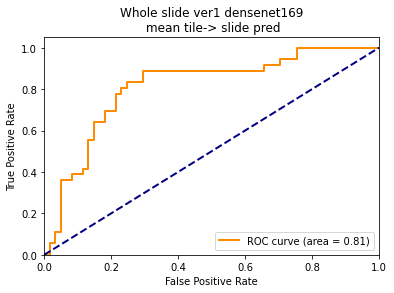

In [10]:
y_score = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1)
y_true = new_slide_df.loc[:,'class'].values
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=True)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whole slide ver1 densenet169\n mean tile-> slide pred")
plt.legend(loc="lower right")
plt.show()
